In [54]:
# Imports
import cv2
import numpy as np
# import easyocr
import pytesseract
import mediapipe as mp
import matplotlib.pyplot as plt

In [55]:
# Constants
IMAGE_FILENAME = 'img_hw8.jpg' # misaligned image
IMAGE_H = 4080 # 4080px
IMAGE_W = 3072 # 3072px
PHYSICAL_H = 28 # 28cm
PHYSICAL_W = 21.5 # 21.5cm
SCALE_Y = IMAGE_H/PHYSICAL_H # 146 pixels per 1 cm, rounding up (4080px/28cm).
SCALE_X = IMAGE_W/PHYSICAL_W # 143 pixels per 1 cm, rounding up (3072px/21.5cm).
Y_MIN = -14 # -(PHYSICAL_H/2)
X_MIN = -10.75 # -(PHYSICAL_W/2)

In [56]:
"""
Converts physical centimeter coordinates and size to pixel coordinates.

Args:
    x_cm (float): X-coordinate in centimeters.
    y_cm (float): Y-coordinate in centimeters.
    w_cm (float): Width of target in centimeters.
    h_cm (float): Height of target in centimeters.
    
Returns:
    x_pix (float): X-coordinate converted to pixels.
    y_pix (float): Y-coordinate converted to pixels.
    w_pix (float): Width of target converted to pixels.
    h_pix (float): Height of target converted to pixels.
"""
def cm_to_pixels(x_cm, y_cm, w_cm, h_cm):
    x_pix = int((x_cm - X_MIN) * SCALE_X)
    y_pix = int((y_cm - Y_MIN) * SCALE_Y)
    w_pix = int(w_cm * SCALE_X)
    h_pix = int(h_cm * SCALE_Y)
    return x_pix, y_pix, w_pix, h_pix

## Parts 1, 2, and 3

1. Print the image (or hard copies will be given in class) and fill out the "your name", the 1390 vs 2390 checkbox, and enter a random 5 digit number

2. Take a photograph of the paper

3. Using the ACUCO symbols, align and orient the photograph

Text(0.5, 1.0, 'Aligned Image')

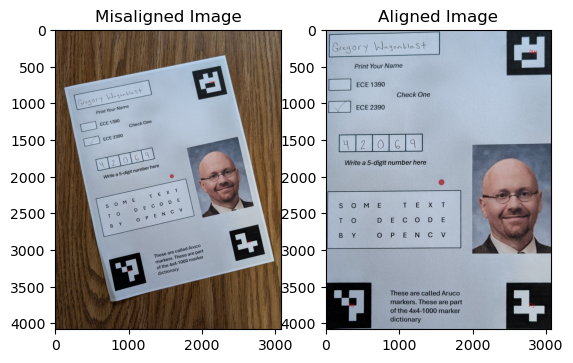

In [57]:
img = cv2.imread(IMAGE_FILENAME)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

dictionary=cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_1000)
corners, ids, rejected = cv2.aruco.detectMarkers(img, dictionary)

# Destination points (where the corners should map to for perfect alignment).
pts_dst = np.float32([[0, 0], [IMAGE_W, 0], [IMAGE_W, IMAGE_H], [0, IMAGE_H]])
pts_src = [] # Source points, to be detetmined.

for idx in range(0,ids.shape[0]):
    thiscorner=corners[idx][0]
    pos=np.uint16(thiscorner.mean(axis=0))
    pts_src.append(thiscorner)
    cv2.putText(img,f"{ids[idx]}",pos,cv2.FONT_HERSHEY_SIMPLEX,1,(255,0,0),2)

# Assuming marker 1 is BL, marker 2 is BR, marker 3 is TR.
P_BL = pts_src[0][3]  # Bottom-Left point of Marker 1
P_BR = pts_src[1][2]  # Bottom-Right point of Marker 2
P_TR = pts_src[2][1]  # Top-Right point of Marker 3

# Estimate the missing top-left corner.
P_TL = P_BL + P_TR - P_BR - [0, 150] # Constant for getting the name box fully in the image.

# Source points.
pts_src = np.float32([P_TL, P_TR, P_BR, P_BL])

# Alignment step.
M = cv2.getPerspectiveTransform(pts_src, pts_dst)
img_aligned = cv2.warpPerspective(img, M, (IMAGE_W, IMAGE_H))

plt.subplot(121); plt.imshow(img); plt.title("Misaligned Image")
plt.subplot(122); plt.imshow(img_aligned); plt.title("Aligned Image")

## Part 4

4. Using EasyOCR, read in the name box that you wrote

In [58]:
"""
Gets the region of interest to perform OCR on.

Args:
    img_aligned (np.array): Aligned image to extract ROI from.
    x_name (float): X-coordinate in centimeters.
    y_name (float): Y-coordinate in pixels.
    w_name (float): Width of target in pixels.
    h_name (float): Height of target in pixels.
    
Returns:
    thresh (np.array): The region of interest thresholded.
"""
def get_roi(img_aligned, x_pix, y_pix, w_pix, h_pix):
    img_gray = cv2.cvtColor(img_aligned, cv2.COLOR_BGR2GRAY)

    pts = np.array([
        [x_pix - 50, y_pix],                # Top-Left
        [x_pix + w_pix, y_pix],            # Top-Right
        [x_pix + w_pix, y_pix + h_pix],   # Bottom-Right
        [x_pix - 50, y_pix + h_pix]        # Bottom-Left
    ], dtype=np.int32)

    cv2.polylines(img_aligned, [pts], True, (0, 255, 0), 8)

    mask = np.zeros(img_gray.shape, dtype=np.uint8)
    cv2.fillPoly(mask, [pts], 255)

    masked = cv2.bitwise_and(img_gray, img_gray, mask=mask)

    ptsIdeal = np.array([[0,0],[1000,0],[1000,1000],[0,1000]])

    M =cv2.getPerspectiveTransform(np.float32(pts),np.float32(ptsIdeal))

    gray_warped = cv2.warpPerspective(img_gray,M,(1000,1000))

    thresh = cv2.threshold(gray_warped, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)[1]

    plt.subplot(141); plt.imshow(img_aligned)
    plt.subplot(142); plt.imshow(masked,cmap='gray')
    plt.subplot(143); plt.imshow(gray_warped,cmap='gray')
    plt.subplot(144); plt.imshow(thresh,cmap='gray')
    plt.tight_layout()

    return thresh, gray_warped

--- Recognized Text ---
—_——



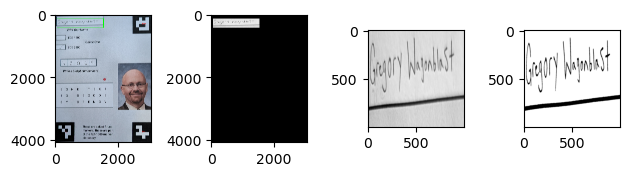

In [59]:
# reader = easyocr.Reader(['en'])

# TEXT BOX.  
# [H,W] = 2cm x 10cm 
# [X,Y] = [-10cm, -13cm]
x_pix, y_pix, w_pix, h_pix = cm_to_pixels(-10, -13, 10, 2)

thresh, _ = get_roi(img_aligned, x_pix, y_pix, w_pix, h_pix)

# Perform OCR
result = pytesseract.image_to_string(thresh, config='--psm 6') # Assume a single uniform block of text.
print("--- Recognized Text ---")
print(result)
# result = reader.readtext(gray_warped)
# df=pd.DataFrame(result)
# print(result)

<span style="color:gray">I am having a lot of difficulty setting up the environment for EasyOCR compatability. Using pytesseract instead. Some text is "recognized" but accuracy is %0.</span>

## Part 5
5. Write code to check which of the two checkboxes is marked by comparing the intensity in the two boxes

In [60]:
"""
Compares the mean intensity of two checkbox regions to determine which is checked.
A checked box will have a higher mean intensity (darker).

Args:
    img_aligned (np.array): Aligned image to extract mean intensity from.
    coords (np.array): Relevant pixel coordinates to use.
    
Returns:
    thresh (np.array): The region of interest thresholded.
"""
def get_mean_intensity(img_aligned, coords):
    (x_pix, y_pix, w_pix, h_pix) = coords

    # Crop the region of interest.
    roi = img_aligned[y_pix:(y_pix+h_pix), x_pix:(x_pix+w_pix)]

    # Convert to grayscale for intensity measurement.
    gray_roi = cv2.cvtColor(roi, cv2.COLOR_RGB2GRAY)

    # Apply a threshold to count black pixels.
    _, thresholded = cv2.threshold(gray_roi, 150, 255, cv2.THRESH_BINARY)

    # Display region of interest.
    plt.imshow(thresholded, cmap='gray')
    
    # Calculate the ratio of black pixels to total pixels.
    black_pixel_count = np.sum(thresholded == 0)
    total_pixels = thresholded.size
    darkness_ratio = black_pixel_count / total_pixels

    return darkness_ratio


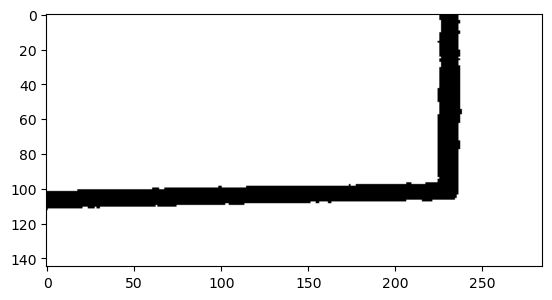

In [61]:
# Checkbox ECE-1390 
# [H,W] = 1cm x 2cm 
# [X,Y] = [-10cm, -9cm]
x_pix, y_pix, w_pix, h_pix = cm_to_pixels(-10, -9, 2, 1)
ratio_a = get_mean_intensity(img_aligned, [x_pix, y_pix, w_pix, h_pix])

Ratio A: 0.08505747126436781
Ratio B: 0.10516636418632788
ECE-2390 is marked (darker).


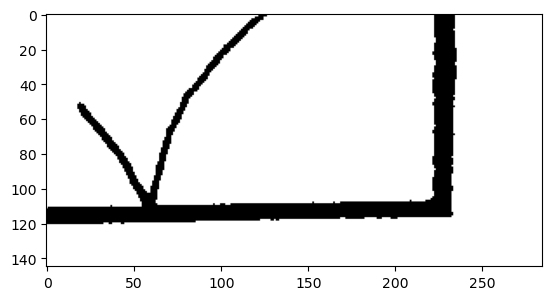

In [62]:
# Checkbox ECE-2390 
# [H,W] = 1cm x 2cm 
# [X,Y] = [-10cm, -7cm]
x_pix, y_pix, w_pix, h_pix = cm_to_pixels(-10, -7, 2, 1)
ratio_b = get_mean_intensity(img_aligned, [x_pix, y_pix, w_pix, h_pix])

print(f"Ratio A: {ratio_a}")
print(f"Ratio B: {ratio_b}")

if ratio_a > ratio_b:
    print("ECE-1390 is marked (darker).")
elif ratio_b > ratio_a:
    print("ECE-2390 is marked (darker).")
else:
    print("Cannot differentiate.")

## Part 6
6) Using the example from class on OCR-digits, decode the 5 numbers you wrote


SVM and KNearest digit recognition.

Sample loads a dataset of handwritten digits from 'digits.png'.
Then it trains a SVM and KNearest classifiers on it and evaluates
their accuracy.

Following preprocessing is applied to the dataset:
 - Moment-based image deskew (see deskew())
 - Digit images are split into 4 10x10 cells and 16-bin
   histogram of oriented gradients is computed for each
   cell
 - Transform histograms to space with Hellinger metric (see [1] (RootSIFT))


[1] R. Arandjelovic, A. Zisserman
    "Three things everyone should know to improve object retrieval"
    http://www.robots.ox.ac.uk/~vgg/publications/2012/Arandjelovic12/arandjelovic12.pdf

Usage:
   digits.py

Loading SVM and K-Nearest models...
Preprocessing...
Predicting results...

Recognized 5-Digit Number (SVM): 42044

Recognized 5-Digit Number (K-Nearest): 28084


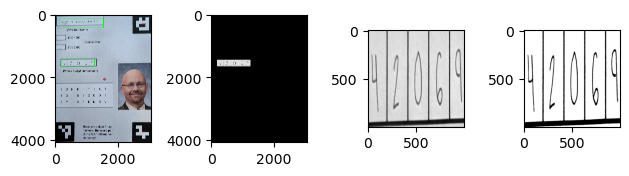

In [63]:
#!/usr/bin/env python

'''
SVM and KNearest digit recognition.

Sample loads a dataset of handwritten digits from 'digits.png'.
Then it trains a SVM and KNearest classifiers on it and evaluates
their accuracy.

Following preprocessing is applied to the dataset:
 - Moment-based image deskew (see deskew())
 - Digit images are split into 4 10x10 cells and 16-bin
   histogram of oriented gradients is computed for each
   cell
 - Transform histograms to space with Hellinger metric (see [1] (RootSIFT))


[1] R. Arandjelovic, A. Zisserman
    "Three things everyone should know to improve object retrieval"
    http://www.robots.ox.ac.uk/~vgg/publications/2012/Arandjelovic12/arandjelovic12.pdf

Usage:
   digits.py
'''


# Python 2/3 compatibility
from __future__ import print_function

import numpy as np
import cv2 as cv

# built-in modules
from multiprocessing.pool import ThreadPool

from numpy.linalg import norm

# local modules
from common import clock, mosaic

import os
from pathlib import Path

SZ = 20 # size of each digit is SZ x SZ
CLASS_N = 10

DIGITS_FN = 'digits.png'

def split2d(img, cell_size, flatten=True):
    h, w = img.shape[:2]
    sx, sy = cell_size
    cells = [np.hsplit(row, w//sx) for row in np.vsplit(img, h//sy)]
    cells = np.array(cells)
    if flatten:
        cells = cells.reshape(-1, sy, sx)
    return cells

def load_digits(fn):
    #fn = cv.samples.findFile(fn)
    print('loading "%s" ...' % fn)
    digits_img = cv.imread(fn, cv.IMREAD_GRAYSCALE)
    digits = split2d(digits_img, (SZ, SZ))
    labels = np.repeat(np.arange(CLASS_N), len(digits)/CLASS_N)
    return digits, labels

def deskew(img):
    m = cv.moments(img)
    if abs(m['mu02']) < 1e-2:
        return img.copy()
    skew = m['mu11']/m['mu02']
    M = np.float32([[1, skew, -0.5*SZ*skew], [0, 1, 0]])
    img = cv.warpAffine(img, M, (SZ, SZ), flags=cv.WARP_INVERSE_MAP | cv.INTER_LINEAR)
    return img


class KNearest(object):
    def __init__(self, k = 3):
        self.k = k
        self.model = cv.ml.KNearest_create()

    def train(self, samples, responses):
        self.model.train(samples, cv.ml.ROW_SAMPLE, responses)

    def predict(self, samples):
        _retval, results, _neigh_resp, _dists = self.model.findNearest(samples, self.k)
        return results.ravel()

    def load(self, fn):
        self.model = cv.ml.KNearest_load(fn)

    def save(self, fn):
        self.model.save(fn)

class SVM(object):
    def __init__(self, C = 1, gamma = 0.5):
        self.model = cv.ml.SVM_create()
        self.model.setGamma(gamma)
        self.model.setC(C)
        self.model.setKernel(cv.ml.SVM_RBF)
        self.model.setType(cv.ml.SVM_C_SVC)

    def train(self, samples, responses):
        self.model.train(samples, cv.ml.ROW_SAMPLE, responses)

    def predict(self, samples):
        return self.model.predict(samples)[1].ravel()

    def load(self, fn):
        self.model = cv.ml.SVM_load(fn)

    def save(self, fn):
        self.model.save(fn)

def evaluate_model(model, digits, samples, labels):
    resp = model.predict(samples)
    err = (labels != resp).mean()
    print('error: %.2f %%' % (err*100))

    confusion = np.zeros((10, 10), np.int32)
    for i, j in zip(labels, resp):
        confusion[i, int(j)] += 1
    print('confusion matrix:')
    print(confusion)
    print()

    vis = []
    for img, flag in zip(digits, resp == labels):
        img = cv.cvtColor(img, cv.COLOR_GRAY2BGR)
        if not flag:
            img[...,:2] = 0
        vis.append(img)
    return mosaic(25, vis)

def preprocess_simple(digits):
    return np.float32(digits).reshape(-1, SZ*SZ) / 255.0

def preprocess_hog(digits):
    samples = []
    for img in digits:
        gx = cv.Sobel(img, cv.CV_32F, 1, 0)
        gy = cv.Sobel(img, cv.CV_32F, 0, 1)
        mag, ang = cv.cartToPolar(gx, gy)
        bin_n = 16
        bin = np.int32(bin_n*ang/(2*np.pi))
        bin_cells = bin[:10,:10], bin[10:,:10], bin[:10,10:], bin[10:,10:]
        mag_cells = mag[:10,:10], mag[10:,:10], mag[:10,10:], mag[10:,10:]
        hists = [np.bincount(b.ravel(), m.ravel(), bin_n) for b, m in zip(bin_cells, mag_cells)]
        hist = np.hstack(hists)

        # transform to Hellinger kernel
        eps = 1e-7
        hist /= hist.sum() + eps
        hist = np.sqrt(hist)
        hist /= norm(hist) + eps

        samples.append(hist)
    return np.float32(samples)


if __name__ == '__main__':
    print(__doc__)

    # 5-digit number 
    # [H,W] = 1.5cm x 1.5cm 
    # [X,Y] = [{-9,-7.5,-6.-4.5,-3} cm,-4cm]
    x_name, y_name, w_name, h_name = cm_to_pixels(-9, -4, 7, 1.5)

    # Get region of interest.
    digits_roi, _ = get_roi(img_aligned, x_name, y_name, w_name, h_name)

    # Resize the cropped area to the exact dimensions needed for the OCR script (20x100).
    img_resized = cv2.resize(digits_roi, (100, 20), interpolation=cv2.INTER_AREA)

    # Load the models from the saved digits_*.dat files.
    print('Loading SVM and K-Nearest models...')

    model_svm = SVM(C=2.67, gamma=5.383)
    model_svm.load('digits_svm.dat')

    model_knearest = KNearest(k=4)
    model_knearest.load('digits_knearest.dat')

    # Preprocess the five digits.
    print('Preprocessing...')

    digits_svm = split2d(img_resized, (SZ, SZ)) # Split the 100x20 ROI into five 20x20 cells.
    digits2_svm = list(map(deskew, digits_svm))
    samples_svm = preprocess_hog(digits2_svm)

    digits_knearest = split2d(img_resized, (SZ, SZ)) # Split the 100x20 ROI into five 20x20 cells.
    digits2_knearest = list(map(deskew, digits_knearest))
    samples_knearest = preprocess_hog(digits2_knearest)

    # Predict the five digits.
    print('Predicting results...')

    predicted_labels_svm = model_svm.predict(samples_svm)
    
    predicted_labels_knearest = model_knearest.predict(samples_knearest)

    # Output.
    recognized_number_svm = "".join(map(str, np.int32(predicted_labels_svm)))
    print(f'\nRecognized 5-Digit Number (SVM): {recognized_number_svm}')

    recognized_number_knearest = "".join(map(str, np.int32(predicted_labels_knearest)))
    print(f'\nRecognized 5-Digit Number (K-Nearest): {recognized_number_knearest}')

<span style="color:gray">The SVM prediction method has an accuracy of %60 and the K-Nearest prediction method has an accuracy of %20 in this case.</span>

## Part 7
7) Using Tesseract-OCR, read the printed text box ("some test to decode by openCV')

--- Recognized Text ---
SOME TEXT
TQ DECODE
BY QPENCY



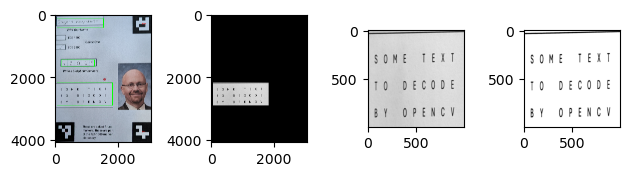

In [64]:
# Some Text to decode
# [H,W] = 5cm x 12cm	
# [X,Y] = [-10cm, 1cm]
x_pix, y_pix, w_pix, h_pix = cm_to_pixels(-10, 1, 12, 5)

thresh, _ = get_roi(img_aligned, x_pix, y_pix, w_pix, h_pix)

# Perform OCR
result = pytesseract.image_to_string(thresh, config='--psm 6') # Assume a single uniform block of text.
print("--- Recognized Text ---")
print(result)

<span style="color:gray">Not bad, accuracy of %92.5 (25/27) when accounting for white spaces.</span>

## Part 8
8) Using MediaPipe, find the facial features for the image of Dr Huppert and draw the markers on the image.

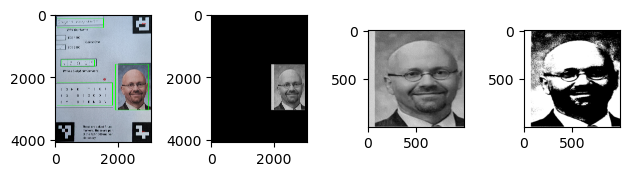

In [65]:
# Face Picture
# [H,W] = 10cm x 7cm	
# [X,Y] = [3cm, -3cm]
x_pix, y_pix, w_pix, h_pix = cm_to_pixels(3, -3, 7, 10)

thresh, gray_warped = get_roi(img_aligned, x_pix, y_pix, w_pix, h_pix)

# Initialize MediaPipe Face Mesh and set up drawing styles for the markers and connections.
mp_face_mesh = mp.solutions.face_mesh
mp_drawing = mp.solutions.drawing_utils
drawing_spec = mp_drawing.DrawingSpec(thickness=1, circle_radius=1)

In [66]:
"""
Processes a NumPy array grayscale image to find and draw MediaPipe Face Mesh landmarks.

Args:
    img_aligned (np.array): Aligned image to draw markers on.
    
Returns:
    img_rgb (np.array):  The RGB image with the markers drawn on.
"""
def draw_markers(img_aligned):
    # Convert the gray scale image to RGB for MediaPipe processing, MediaPipe requires 3 channels.
    img_rgb = cv2.cvtColor(img_aligned, cv2.COLOR_GRAY2RGB)

    # Process the image with the Face Mesh model.
    with mp_face_mesh.FaceMesh(
        static_image_mode=True,
        max_num_faces=1, 
        min_detection_confidence=0.5
    ) as face_mesh:
        results = face_mesh.process(img_rgb)

    # Check if any facial landmarks were detected.
    if not results.multi_face_landmarks:
        print("No facial landmarks detected.")
        return img_rgb

    # Draw markers by conneecting a mesh.
    for face_landmarks in results.multi_face_landmarks:
        mp_drawing.draw_landmarks(
            image=img_rgb,
            landmark_list=face_landmarks,
            connections=mp_face_mesh.FACEMESH_TESSELATION, 
            landmark_drawing_spec=None,
            connection_drawing_spec=drawing_spec
        )

    return img_rgb

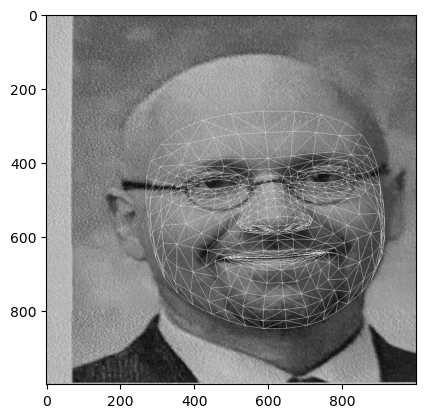

In [68]:
# Process the image.
result = draw_markers(gray_warped)

# Display.
plt.imshow(result)